Lutas REALIZADO: 4141 | Período: 2012-2026
Decisivas: 4107 | Title fights: 130

[Q1] Spearman (year vs duration, non-title): rho=0.132, p=8.054e-17, n=3976

[Q2] Qui-quadrado pre/post-2020: chi2=41.41, p=5.354e-09, V de Cramer=0.100, n=4107

[Q3] Classes analisadas: 9
                       n    mean   std  median
weight_class_clean                            
Heavyweight          401  188.41  5.88  187.96
Light Heavyweight    498  184.57  4.90  184.15
Middleweight         723  182.17  4.45  182.88
Welterweight         977  180.11  4.45  180.34
Lightweight         1350  176.21  4.07  175.26
Catchweight          209  173.69  7.02  172.72
Featherweight       1291  173.68  3.99  172.72
Bantamweight        1282  170.83  4.66  170.18
Flyweight            852  168.25  4.47  167.64

[Q4] Resultados por classe:
            group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
     Bantamweight 476    0.5441  0.4992   0.5883   0.0601      0.5409        False
      Lightweight 4

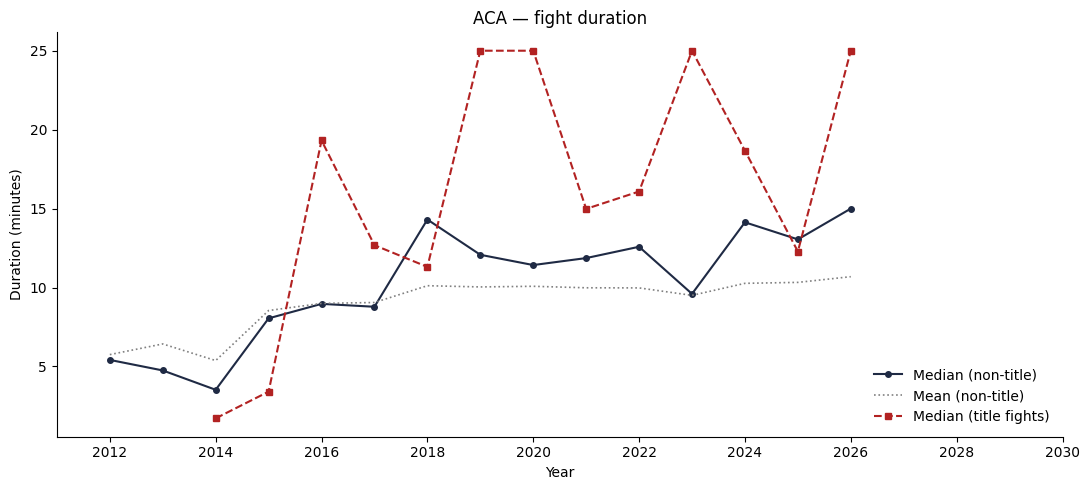

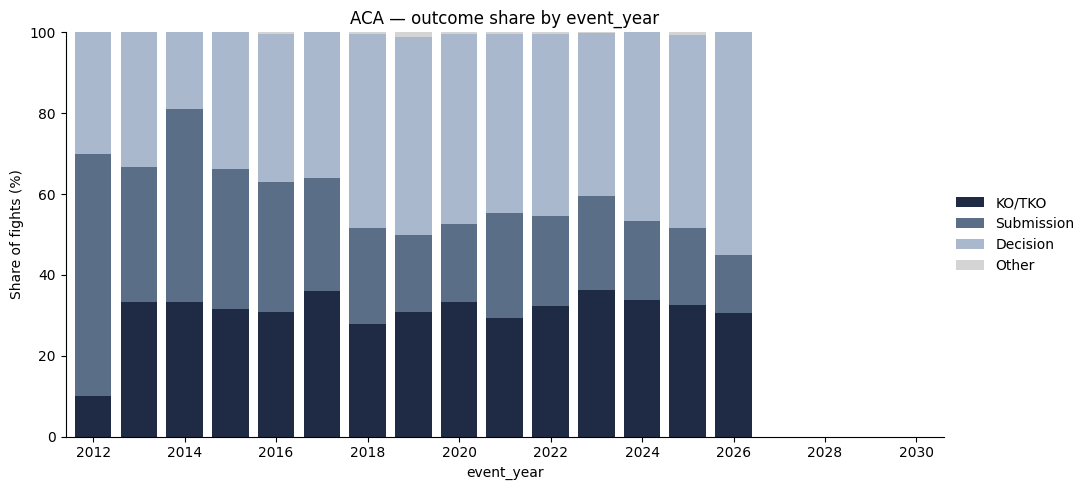

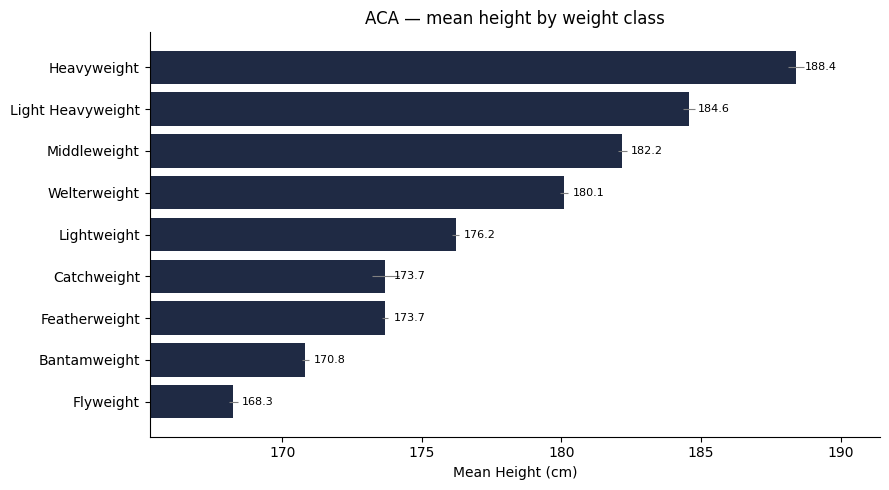

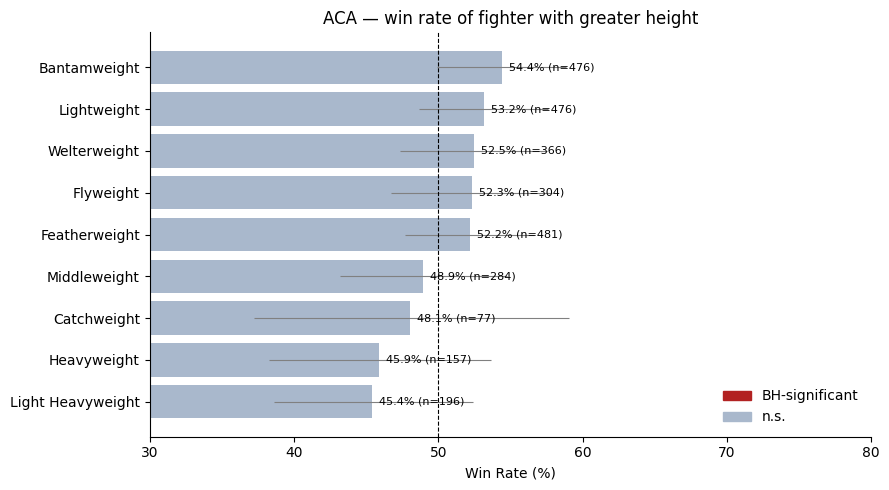

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/aca-mma-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_aca.csv'
JSON_PATH = f'{DATA_DIR}/aca_master_win_title_data.json'


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_aca():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True, errors='coerce')
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            return (int(row['round_num']) - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df, x_max=2030):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color='#1f2a44',
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color='#b22222',
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('ACA — fight duration')
    ax.legend(loc='lower right', frameon=False)
    ax.set_xlim(df['event_year'].min() - 1, x_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2020, x_max=2030):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {'KO/TKO': '#1f2a44', 'Submission': '#5b6e88',
               'Decision': '#a9b8cc', 'Other': '#d4d4d4'}
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat, color=palette[cat])
        bottom += props[cat].values
    ax.set_xlabel('event_year')
    ax.set_ylabel('Share of fights (%)')
    ax.set_title('ACA — outcome share by event_year')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_ylim(0, 100)
    ax.set_xlim(props.index.min() - 0.6, x_max + 0.6)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    desc_sorted = desc.sort_values('mean')
    ax.barh(desc_sorted.index, desc_sorted['mean'], color='#1f2a44',
            xerr=desc_sorted['std'] / np.sqrt(desc_sorted['n']),
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + 0.3, i, f"{row['mean']:.1f}",
                va='center', fontsize=8)
    ax.set_xlabel('Mean Height (cm)')
    ax.set_title('ACA — mean height by weight class')
    ax.set_xlim(desc_sorted['mean'].min() - 3, desc_sorted['mean'].max() + 3)
    sns.despine()
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    valid = res[~res['underpowered']].copy()
    valid = valid.sort_values('win_rate')
    colors = ['#b22222' if s else '#a9b8cc' for s in valid['significant']]
    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[(valid['win_rate'] - valid['ci_low']) * 100,
                  (valid['ci_high'] - valid['win_rate']) * 100],
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    ax.axvline(50, ls='--', color='black', linewidth=0.8)
    for i, (_, row) in enumerate(valid.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.5, i,
                f"{row['win_rate']*100:.1f}% (n={row['n']})",
                va='center', fontsize=8)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('ACA — win rate of fighter with greater height')
    ax.set_xlim(30, 80)
    handles = [plt.Rectangle((0, 0), 1, 1, color='#b22222'),
               plt.Rectangle((0, 0), 1, 1, color='#a9b8cc')]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right', frameon=False)
    sns.despine()
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_aca()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_aca_duration.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2020)
    fig2.savefig('q2_aca_outcomes.png', dpi=120, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2020: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_aca_height.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_aca_height_winrate.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time
The series shows a strong upward shift in fight duration across the 2012-2026 window. The non-title median starts at very low levels in the early period (3-5 minutes in 2012-2014), climbs sharply through the middle years (8-9 minutes in 2015-2016, 14 minutes in 2018), and stabilizes in the 9.5-15 minute range from 2019 onward. The early-period values indicate that the promotion produced near-immediate finishes in its first three years, with most fights concluded inside the first round.

The mean tracks above the median in the early years (the early-period mean is roughly 5-6 minutes while the median sits at 3-5 minutes), which is consistent with a distribution containing a small number of long fights pulling the average up while the bulk of the fights end quickly. From 2018 onward, the mean and median converge, indicating a more symmetric distribution.
The 2026 datapoint (15 minutes) sits at the top of the recent range and should be read with caution since the year may be incomplete relative to the full calendar.

Title fights (red dashed line, n = 130 across 15 years) display extreme year-to-year volatility, particularly in the early period. Annual medians range from roughly 2 minutes (2014) to 25 minutes (2019, 2023, 2026). The early-period title medians (2014: 2 min, 2015: 3 min) reflect very fast finishes in championship bouts, consistent with the broader pattern of early-era fights ending quickly. From 2019 onward, multiple years reach the 25-minute regulation ceiling, indicating title fights routinely go the full distance in the recent era.
The combined picture is of a promotion that began with a fast-finish profile and has converged toward longer fights as the roster has matured and matchmaking has shifted toward closer competitive parity.

## Q2 > Outcome Distribution Over Time
The outcome composition shows a strong statistically significant change across the pre/post-2020 split. The test returns χ² = 41.41, p = 5.35e-09, with Cramér's V = 0.100. The null hypothesis of no association between period and outcome composition is rejected, and the effect size sits in the small-to-moderate range. The very low p-value reflects both the size of the change and the large sample available for the test.

Year-by-year visual composition tracks the shift clearly. The 2012 datapoint is dominated by submissions (roughly 60% of decisive fights) with KO/TKO at only 10%, suggesting a small founding-year sample with strong stylistic skew or a roster heavily weighted toward grappling specialists. From 2013-2017, the composition rebalances: KO/TKO climbs into the 28-36% range, submissions compress to 30-35%, and decisions stabilize around 33-37%. From 2018 onward, the composition takes its modern form: KO/TKO stable around 30%, submissions compressed to 15-20%, and decisions climbing into the 45-50% range.

The pattern is consistent with a roster transition from grappling-dominant specialists toward a more rounded modern athlete profile. The promotion draws from the Caucasus region (Chechnya, Dagestan, broader Russia) where wrestling and grappling lineages are deeply embedded in the regional sporting culture. The early years reflect this lineage directly in the submission share, while the later years show convergence toward a balanced striking-and-grappling product as matchmaking has shifted toward elite competitive parity.

## Q3 > Mean Height by Weight Class
The ordinal progression is clean and well-behaved across all nine analyzed classes. Heavyweight (188.4 cm, n = 401) leads, followed by Light Heavyweight (184.6 cm, n = 498), with a 3.8 cm gap between the two top divisions. This is a healthy separation and indicates that the Heavyweight class has access to a substantial 190+ cm fighter pool. The within-class standard deviations are tight (4.0 to 5.0 cm in most divisions), indicating consistent roster construction across the weight categories.

The absolute height levels sit close to international medians, consistent with a roster drawn primarily from the Caucasus region and broader Russia. Russian adult male mean stature is approximately 177-178 cm, and the Caucasus populations sit in a similar range. The Lightweight (176.2 cm) and Featherweight (173.7 cm) means align with what would be expected from this demographic baseline, and the heavier divisions reflect the upper portion of the same distribution. The lighter classes show no pronounced demographic shift in either direction relative to international medians.

The dataset has no Strawweight class, suggesting the promotion operates primarily as a male-only product or with insufficient women's representation to reach the n ≥ 10 threshold. This is consistent with the regional cultural context where women's MMA participation is limited.
The Catchweight bucket (173.7 cm, n = 209) is one of the smaller categories at this promotion relative to its scale elsewhere in the analysis and has the highest within-class standard deviation (7.02 cm vs 4.0 to 5.0 cm in the standard divisions). The mean coincides with the Featherweight mean, but this is coincidental and reflects the central tendency of the matched weights rather than a comparable distribution.

The sample sizes are very substantial across the major divisions (Lightweight n = 1350, Featherweight n = 1291, Bantamweight n = 1282), which produces tight confidence intervals for the descriptive estimates.

## Q4 > Win Rate by Height Advantage
No class reaches statistical significance after correcting for multiple testing, and no class reaches raw significance below α = 0.05 either. Bantamweight has the lowest raw p-value at 0.060, which is marginal. The formal conclusion is that the evidence is insufficient to reject the null hypothesis of no height effect in any division.

The directional pattern is distinctive and shows a clear inversion across weight ranges. The lighter and middle classes show the taller fighter winning slightly more often: Bantamweight (54.4%, n = 476), Lightweight (53.2%, n = 476), Welterweight (52.5%, n = 366), Flyweight (52.3%, n = 304), and Featherweight (52.2%, n = 481). The heavier classes, in contrast, show the shorter fighter winning more often: Middleweight (48.9%, n = 284), Catchweight (48.1%, n = 77), Heavyweight (45.9%, n = 157), and Light Heavyweight (45.4%, n = 196).

The reversal in the heavier divisions is the most notable feature of the dataset. Light Heavyweight at 45.4% and Heavyweight at 45.9% sit roughly 4-5 percentage points below the baseline with substantial sample sizes (n ≥ 157 in both). This pattern is structurally consistent with the roster's grappling lineage. In heavier classes, leverage advantages from a lower center of gravity, a stronger base for wrestling exchanges, and shorter limbs for clinch and ground positions can offset the reach advantage that height typically provides. The roster's grappling-heavy stylistic baseline likely amplifies these counter-advantages, producing the observed reversal.
The lighter classes show the conventional directional pattern of taller-fighter advantage, though all the effects are modest (within 5 percentage points of the baseline). The sample sizes are sufficient to detect larger effects, but the magnitude of the directional signal is not large enough to clear correction at the current sample sizes.

The Catchweight result (48.1%, n = 77) is the smallest sample in the test and is consistent with the structural caveat that applies to that bucket. When fighters are matched across a wide weight range, the height comparison is confounded by the weight asymmetry of the matched pair, and the conditional-on-weight interpretation of the height signal breaks down.

The full pattern across the table, with the heavier classes systematically reversed and the lighter classes mildly favoring the taller fighter, is the most distinctive feature of this analysis and warrants further investigation using continuous height differential as a predictor instead of the dichotomized comparison.